In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)


In [2]:
import os

ejscreen_file = 'EJScreen_2024_Tract_with_AS_CNMI_GU_VI.csv'
svi_file = 'SVI_2022_US_county.csv'
lcv_file = 'moc-listing-2025-06-27.csv'

files_exist = all([os.path.exists(f) for f in [ejscreen_file, svi_file, lcv_file]])


In [3]:
if files_exist:

    ejscreen_df = pd.read_csv(ejscreen_file, low_memory=False)

    svi_df = pd.read_csv(svi_file, low_memory=False)

    lcv_df = pd.read_csv(lcv_file)


In [4]:
ej_cols = ['ID', 'STATE_NAME', 'ST_ABBREV', 'CNTY_NAME', 'ACSTOTPOP',
          'P_DEMOGIDX_2', 'P_PM25', 'P_OZONE', 'P_DSLPM', 'P_LDPNT',
          'P_PNPL', 'P_PRMP', 'P_PTSDF', 'P_UST', 'P_PWDIS']


In [5]:
svi_cols = ['FIPS', 'STATE', 'ST_ABBR', 'COUNTY', 'E_TOTPOP',
            'RPL_THEMES', 'RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4']


In [6]:
lcv_df = pd.read_csv(lcv_file, encoding='utf-8', on_bad_lines='skip')


In [7]:
import csv

lcv_data = []
current_state = None

with open(lcv_file, 'r', encoding='utf-8') as f:

    next(f)

    reader = csv.DictReader(f)

    for row in reader:

        if row['First Name'] and (not row['Last Name'] or row['Last Name'].strip() == ''):
            current_state = row['First Name']

        elif row.get('Party') in ['D', 'R', 'I']:
            row['State'] = current_state
            lcv_data.append(row)

lcv_clean = pd.DataFrame(lcv_data)

lcv_clean['Year Score'] = pd.to_numeric(lcv_clean['Year Score'], errors='coerce')
lcv_clean['Lifetime Score'] = pd.to_numeric(lcv_clean['Lifetime Score'], errors='coerce')


In [8]:
env_cols = ['P_PM25', 'P_OZONE', 'P_DSLPM', 'P_LDPNT', 'P_PNPL',
            'P_PRMP', 'P_PTSDF', 'P_UST', 'P_PWDIS', 'P_DWATER']

demo_cols = ['P_DEMOGIDX_2', 'P_LOWINCPCT', 'P_PEOPCOLORPCT', 'P_LINGISOPCT']

ejscreen_df['ENV_BURDEN'] = ejscreen_df[env_cols].mean(axis=1)
ejscreen_df['DEMO_BURDEN'] = ejscreen_df[demo_cols].mean(axis=1)
ejscreen_df['EJ_COMPOSITE'] = (ejscreen_df['ENV_BURDEN'] + ejscreen_df['DEMO_BURDEN']) / 2

ejscreen_df['COUNTY_FIPS'] = ejscreen_df['ID'].astype(str).str[:5]


In [9]:
county_ej = ejscreen_df.groupby(['COUNTY_FIPS', 'STATE_NAME', 'ST_ABBREV', 'CNTY_NAME']).apply(
   lambda x: pd.Series({
       'TOTAL_POP': x['ACSTOTPOP'].sum(),
       'AVG_EJ_COMPOSITE': np.average(x['EJ_COMPOSITE'], weights=x['ACSTOTPOP']) if x['ACSTOTPOP'].sum() > 0 else x['EJ_COMPOSITE'].mean(),
       'AVG_ENV_BURDEN': np.average(x['ENV_BURDEN'], weights=x['ACSTOTPOP']) if x['ACSTOTPOP'].sum() > 0 else x['ENV_BURDEN'].mean(),
       'AVG_DEMO_BURDEN': np.average(x['DEMO_BURDEN'], weights=x['ACSTOTPOP']) if x['ACSTOTPOP'].sum() > 0 else x['DEMO_BURDEN'].mean(),
       'TRACT_COUNT': len(x)
   })
).reset_index()


In [10]:
svi_df['FIPS'] = svi_df['FIPS'].astype(str).str.zfill(5)

svi_cols = ['FIPS', 'RPL_THEMES', 'RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4']
svi_subset = svi_df[svi_cols].copy()

merged_data = county_ej.merge(
    svi_subset,
    left_on='COUNTY_FIPS',
    right_on='FIPS',
    how='left'
)


In [11]:
state_svi_median = svi_df.groupby('ST_ABBR')['RPL_THEMES'].median()

merged_data['RPL_THEMES_FILLED'] = merged_data.apply(
   lambda row: state_svi_median.get(row['ST_ABBREV'], 0.5) if pd.isna(row['RPL_THEMES']) else row['RPL_THEMES'],
   axis=1
)

merged_data['EJ_NORM'] = merged_data['AVG_EJ_COMPOSITE'] / 100
merged_data['COMBINED_VULNERABILITY'] = (merged_data['EJ_NORM'] + merged_data['RPL_THEMES_FILLED']) / 2


In [12]:
state_lcv = lcv_clean.groupby('State').agg({
    'Year Score': 'mean',
    'Lifetime Score': 'mean',
    'Party': lambda x: x.mode()[0] if len(x) > 0 else 'N/A'
}).reset_index()

state_lcv.columns = ['STATE_NAME', 'AVG_YEAR_SCORE', 'AVG_LIFETIME_SCORE', 'DOMINANT_PARTY']

state_lcv['STATE_NAME'] = state_lcv['STATE_NAME'].str.upper()
merged_data['STATE_NAME_UPPER'] = merged_data['STATE_NAME'].str.upper()

final_data = merged_data.merge(
    state_lcv,
    left_on='STATE_NAME_UPPER',
    right_on='STATE_NAME',
    how='left',
    suffixes=('', '_LCV')
)


In [13]:
final_data['LCV_GAP'] = 1 - (final_data['AVG_YEAR_SCORE'] / 100)

final_data['JUSTICE_GAP_SCORE'] = final_data['COMBINED_VULNERABILITY'] * final_data['LCV_GAP']

final_data['JUSTICE_GAP_RANK'] = final_data['JUSTICE_GAP_SCORE'].rank(ascending=False, method='min')

top_gaps = final_data.nlargest(20, 'JUSTICE_GAP_SCORE')[
   ['CNTY_NAME', 'STATE_NAME', 'COMBINED_VULNERABILITY', 'AVG_YEAR_SCORE',
    'JUSTICE_GAP_SCORE', 'JUSTICE_GAP_RANK', 'DOMINANT_PARTY']
]


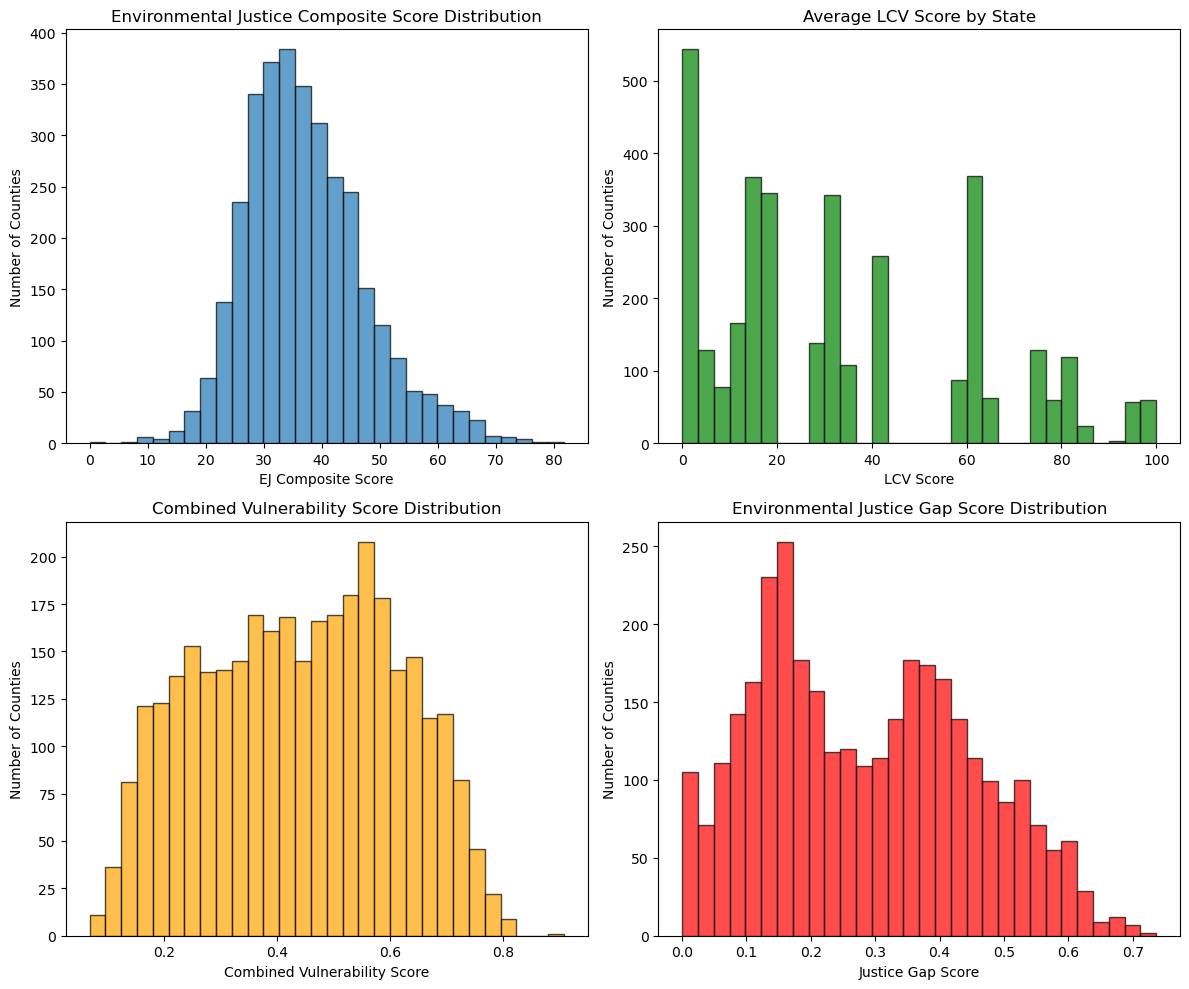

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hist(final_data['AVG_EJ_COMPOSITE'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Environmental Justice Composite Score Distribution')
axes[0, 0].set_xlabel('EJ Composite Score')
axes[0, 0].set_ylabel('Number of Counties')

axes[0, 1].hist(final_data['AVG_YEAR_SCORE'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_title('Average LCV Score by State')
axes[0, 1].set_xlabel('LCV Score')
axes[0, 1].set_ylabel('Number of Counties')

axes[1, 0].hist(final_data['COMBINED_VULNERABILITY'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].set_title('Combined Vulnerability Score Distribution')
axes[1, 0].set_xlabel('Combined Vulnerability Score')
axes[1, 0].set_ylabel('Number of Counties')

axes[1, 1].hist(final_data['JUSTICE_GAP_SCORE'], bins=30, edgecolor='black', alpha=0.7, color='red')
axes[1, 1].set_title('Environmental Justice Gap Score Distribution')
axes[1, 1].set_xlabel('Justice Gap Score')
axes[1, 1].set_ylabel('Number of Counties')

plt.tight_layout()
plt.show()

In [15]:
import os

district_folder = 'state districts'


In [16]:
try:
    import geopandas as gpd
    has_geopandas = True
except ImportError:
    has_geopandas = False

if has_geopandas:

    all_districts = []

    shp_files = [f for f in os.listdir(district_folder) if f.endswith('.shp')]
    state_codes = sorted(list(set([f.split('_')[2] for f in shp_files])))

    for state_code in state_codes[:10]:
        shp_path = os.path.join(district_folder, f'tl_2023_{state_code}_cd118.shp')
        if os.path.exists(shp_path):
            try:
                gdf = gpd.read_file(shp_path)
                gdf['STATE_CODE'] = state_code
                all_districts.append(gdf)
            except Exception as e:
                pass

    if all_districts:
        districts_gdf = pd.concat(all_districts, ignore_index=True)


In [17]:
fips_to_state = {
    '01': 'Alabama', '02': 'Alaska', '04': 'Arizona', '05': 'Arkansas', '06': 'California',
    '08': 'Colorado', '09': 'Connecticut', '10': 'Delaware', '11': 'District of Columbia',
    '12': 'Florida', '13': 'Georgia', '15': 'Hawaii', '16': 'Idaho', '17': 'Illinois',
    '18': 'Indiana', '19': 'Iowa', '20': 'Kansas', '21': 'Kentucky', '22': 'Louisiana',
    '23': 'Maine', '24': 'Maryland', '25': 'Massachusetts', '26': 'Michigan', '27': 'Minnesota',
    '28': 'Mississippi', '29': 'Missouri', '30': 'Montana', '31': 'Nebraska', '32': 'Nevada',
    '33': 'New Hampshire', '34': 'New Jersey', '35': 'New Mexico', '36': 'New York',
    '37': 'North Carolina', '38': 'North Dakota', '39': 'Ohio', '40': 'Oklahoma', '41': 'Oregon',
    '42': 'Pennsylvania', '44': 'Rhode Island', '45': 'South Carolina', '46': 'South Dakota',
    '47': 'Tennessee', '48': 'Texas', '49': 'Utah', '50': 'Vermont', '51': 'Virginia',
    '53': 'Washington', '54': 'West Virginia', '55': 'Wisconsin', '56': 'Wyoming',
    '60': 'American Samoa', '66': 'Guam', '69': 'Northern Mariana Islands',
    '72': 'Puerto Rico', '78': 'Virgin Islands'
}

available_fips = ['01', '02', '04', '05', '06', '08', '09', '10', '11', '12', '13', '15',
                  '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27',
                  '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39',
                  '40', '41', '42', '44', '45', '46', '47', '48', '49', '50', '51', '53',
                  '54', '55', '56', '60', '66', '69', '72', '78']

state_to_fips = {v.upper(): k for k, v in fips_to_state.items()}

final_data['STATE_FIPS'] = final_data['STATE_NAME'].str.upper().map(state_to_fips)

In [18]:
final_data_with_districts = final_data[final_data['STATE_FIPS'].isin(available_fips)].copy()

state_gaps = final_data_with_districts.groupby(['STATE_NAME', 'STATE_FIPS']).agg({
    'JUSTICE_GAP_SCORE': ['mean', 'max', 'std'],
    'COMBINED_VULNERABILITY': 'mean',
    'AVG_YEAR_SCORE': 'mean',
    'TOTAL_POP': 'sum'
}).round(3)

state_gaps.columns = ['_'.join(col).strip() for col in state_gaps.columns]
state_gaps = state_gaps.sort_values('JUSTICE_GAP_SCORE_mean', ascending=False)


In [19]:
priority_counties = final_data_with_districts.nlargest(100, 'JUSTICE_GAP_SCORE')[
    ['STATE_NAME', 'STATE_FIPS', 'CNTY_NAME', 'COUNTY_FIPS', 'TOTAL_POP',
     'AVG_EJ_COMPOSITE', 'AVG_ENV_BURDEN', 'AVG_DEMO_BURDEN',
     'RPL_THEMES_FILLED', 'AVG_YEAR_SCORE', 'DOMINANT_PARTY',
     'JUSTICE_GAP_SCORE', 'JUSTICE_GAP_RANK']
].copy()

priority_counties['EJ_SEVERITY'] = pd.cut(
    priority_counties['AVG_EJ_COMPOSITE'],
    bins=[0, 30, 50, 70, 100],
    labels=['Low', 'Moderate', 'High', 'Severe']
)

priority_counties['POLITICAL_SUPPORT'] = pd.cut(
    priority_counties['AVG_YEAR_SCORE'],
    bins=[-1, 25, 50, 75, 100],
    labels=['Very Low', 'Low', 'Moderate', 'High']
)

display_cols = ['STATE_NAME', 'CNTY_NAME', 'JUSTICE_GAP_SCORE',
                'EJ_SEVERITY', 'POLITICAL_SUPPORT', 'TOTAL_POP']

priority_counties.to_csv('environmental_justice_priority_counties.csv', index=False)


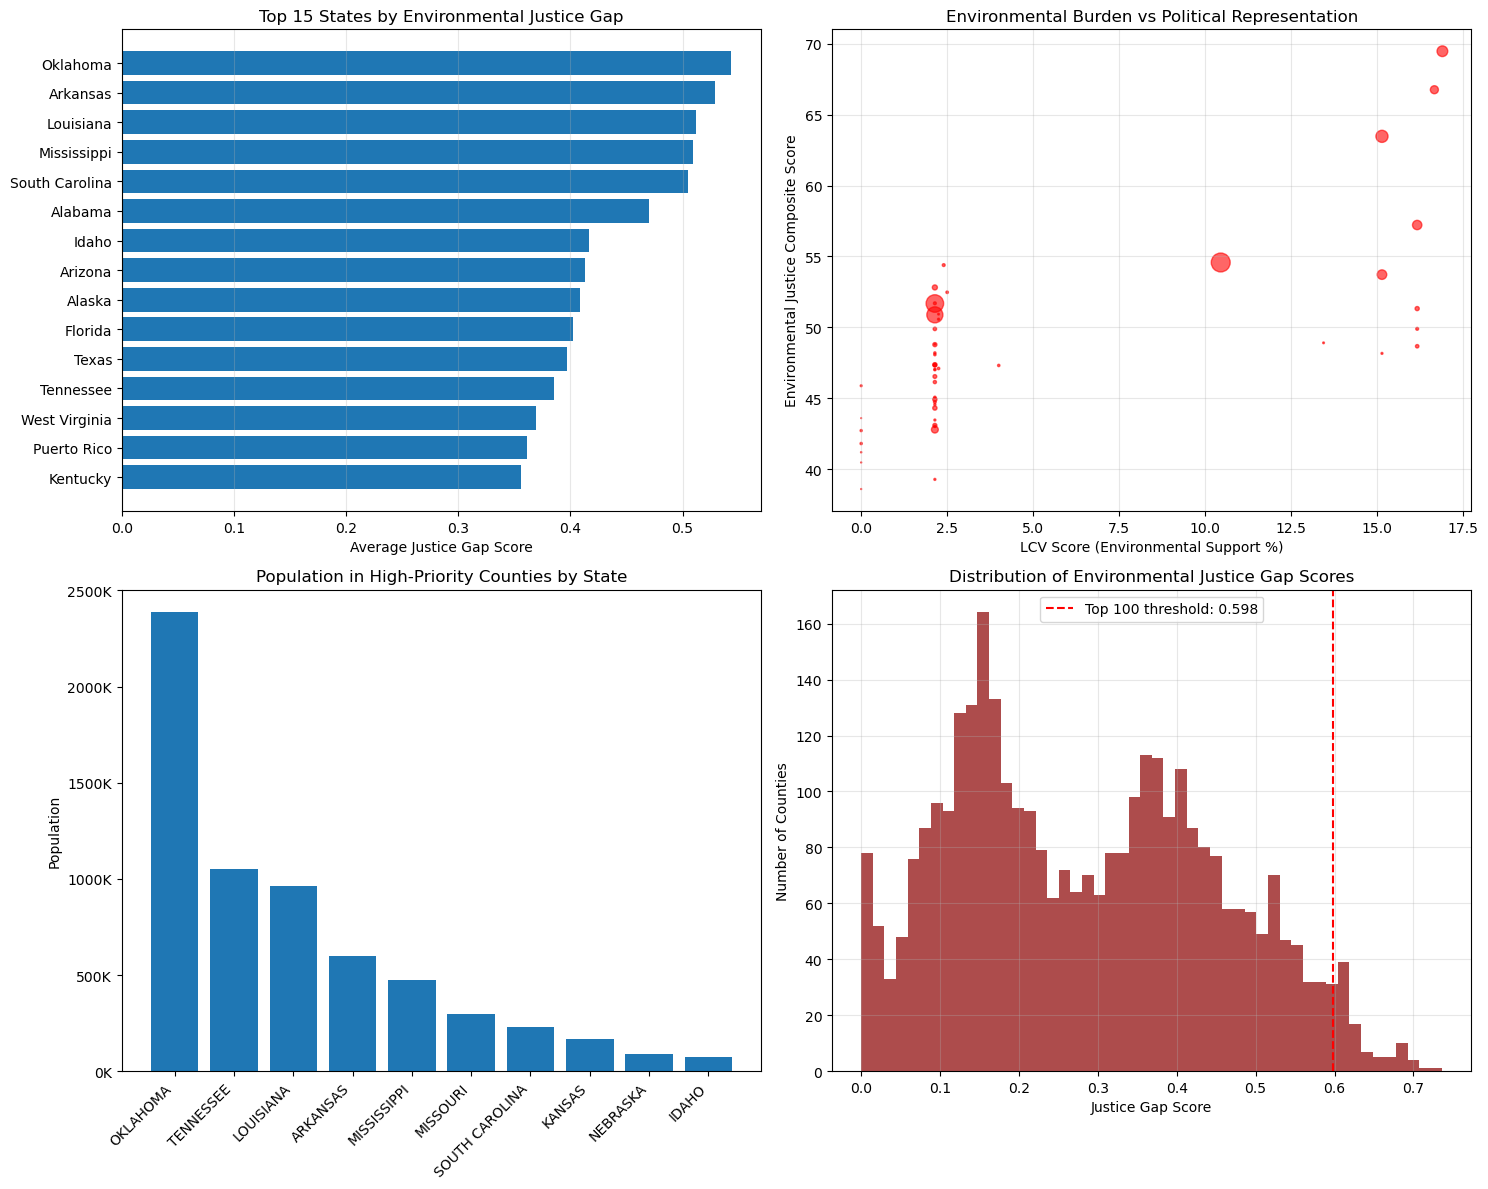

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

top_states = state_gaps.head(15).sort_values('JUSTICE_GAP_SCORE_mean')
axes[0, 0].barh(range(len(top_states)), top_states['JUSTICE_GAP_SCORE_mean'])
axes[0, 0].set_yticks(range(len(top_states)))
axes[0, 0].set_yticklabels([name.title() for name in top_states.index.get_level_values(0)])
axes[0, 0].set_xlabel('Average Justice Gap Score')
axes[0, 0].set_title('Top 15 States by Environmental Justice Gap')
axes[0, 0].grid(axis='x', alpha=0.3)

scatter_data = priority_counties.head(50)
colors = {'R': 'red', 'D': 'blue', 'I': 'green'}
axes[0, 1].scatter(scatter_data['AVG_YEAR_SCORE'],
                   scatter_data['AVG_EJ_COMPOSITE'],
                   s=scatter_data['TOTAL_POP']/5000,
                   c=[colors.get(p, 'gray') for p in scatter_data['DOMINANT_PARTY']],
                   alpha=0.6)
axes[0, 1].set_xlabel('LCV Score (Environmental Support %)')
axes[0, 1].set_ylabel('Environmental Justice Composite Score')
axes[0, 1].set_title('Environmental Burden vs Political Representation')
axes[0, 1].grid(True, alpha=0.3)

pop_by_state = priority_counties.groupby('STATE_NAME')['TOTAL_POP'].sum().sort_values(ascending=False).head(10)
axes[1, 0].bar(range(len(pop_by_state)), pop_by_state.values)
axes[1, 0].set_xticks(range(len(pop_by_state)))
axes[1, 0].set_xticklabels(pop_by_state.index, rotation=45, ha='right')
axes[1, 0].set_ylabel('Population')
axes[1, 0].set_title('Population in High-Priority Counties by State')
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))

axes[1, 1].hist(final_data_with_districts['JUSTICE_GAP_SCORE'], bins=50, color='darkred', alpha=0.7)
axes[1, 1].axvline(priority_counties['JUSTICE_GAP_SCORE'].min(), color='red', linestyle='--',
                   label=f'Top 100 threshold: {priority_counties["JUSTICE_GAP_SCORE"].min():.3f}')
axes[1, 1].set_xlabel('Justice Gap Score')
axes[1, 1].set_ylabel('Number of Counties')
axes[1, 1].set_title('Distribution of Environmental Justice Gap Scores')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('environmental_justice_gap_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
import folium
from shapely.geometry import Point
import json


In [22]:
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')

district_files = [f for f in os.listdir(district_folder) if f.endswith('.shp')]
district_gdfs = []

for shp_file in district_files[:20]:
   try:
       gdf = gpd.read_file(os.path.join(district_folder, shp_file))
       state_fips = shp_file.split('_')[2]
       gdf['STATE_FIPS'] = state_fips
       gdf['STATE_NAME'] = fips_to_state.get(state_fips, 'Unknown')
       district_gdfs.append(gdf)
   except:
       continue

districts_gdf = pd.concat(district_gdfs, ignore_index=True)
districts_gdf['DISTRICT_ID'] = districts_gdf['STATEFP'] + '_' + districts_gdf['CD118FP']

county_burden = ejscreen_df.groupby(['COUNTY_FIPS', 'STATE_NAME', 'ST_ABBREV']).apply(
   lambda x: pd.Series({
       'TOTAL_POP': x['ACSTOTPOP'].sum(),
       'AVG_EJ_COMPOSITE': np.average(x['EJ_COMPOSITE'], weights=x['ACSTOTPOP']) if x['ACSTOTPOP'].sum() > 0 else x['EJ_COMPOSITE'].mean(),
       'AVG_ENV_BURDEN': np.average(x['ENV_BURDEN'], weights=x['ACSTOTPOP']) if x['ACSTOTPOP'].sum() > 0 else x['ENV_BURDEN'].mean(),
       'AVG_DEMO_BURDEN': np.average(x['DEMO_BURDEN'], weights=x['ACSTOTPOP']) if x['ACSTOTPOP'].sum() > 0 else x['DEMO_BURDEN'].mean(),
       'TRACT_COUNT': len(x),
       'HIGH_BURDEN_POP': x[x['EJ_COMPOSITE'] > 60]['ACSTOTPOP'].sum()
   })
).reset_index()


In [23]:
def calculate_justice_gap_index(env_burden, lcv_score):
    protection_deficit = 100 - lcv_score
    return (env_burden * protection_deficit) / 100

analysis_df = county_burden.merge(
    svi_df[['FIPS', 'RPL_THEMES', 'RPL_THEME1', 'RPL_THEME2']],
    left_on='COUNTY_FIPS',
    right_on='FIPS',
    how='left'
)

state_lcv_scores = lcv_clean.groupby('State').agg({
    'Year Score': 'mean',
    'Lifetime Score': 'mean',
    'Party': lambda x: x.mode()[0] if len(x) > 0 else 'N/A'
}).reset_index()
state_lcv_scores.columns = ['STATE_NAME', 'AVG_YEAR_SCORE', 'AVG_LIFETIME_SCORE', 'DOMINANT_PARTY']
state_lcv_scores['STATE_NAME'] = state_lcv_scores['STATE_NAME'].str.upper()

analysis_df = analysis_df.merge(
    state_lcv_scores,
    left_on='STATE_NAME',
    right_on='STATE_NAME',
    how='left'
)

analysis_df['JUSTICE_GAP_INDEX'] = analysis_df.apply(
    lambda x: calculate_justice_gap_index(x['AVG_EJ_COMPOSITE'], x['AVG_YEAR_SCORE']),
    axis=1
)

analysis_df['COMBINED_VULNERABILITY'] = (
    analysis_df['AVG_EJ_COMPOSITE']/100 +
    analysis_df['RPL_THEMES'].fillna(0.5)
) / 2

analysis_df['JUSTICE_GAP_CATEGORY'] = pd.cut(
    analysis_df['JUSTICE_GAP_INDEX'],
    bins=[0, 20, 40, 60, 80, 100],
    labels=['Minimal', 'Low', 'Moderate', 'High', 'Severe']
)


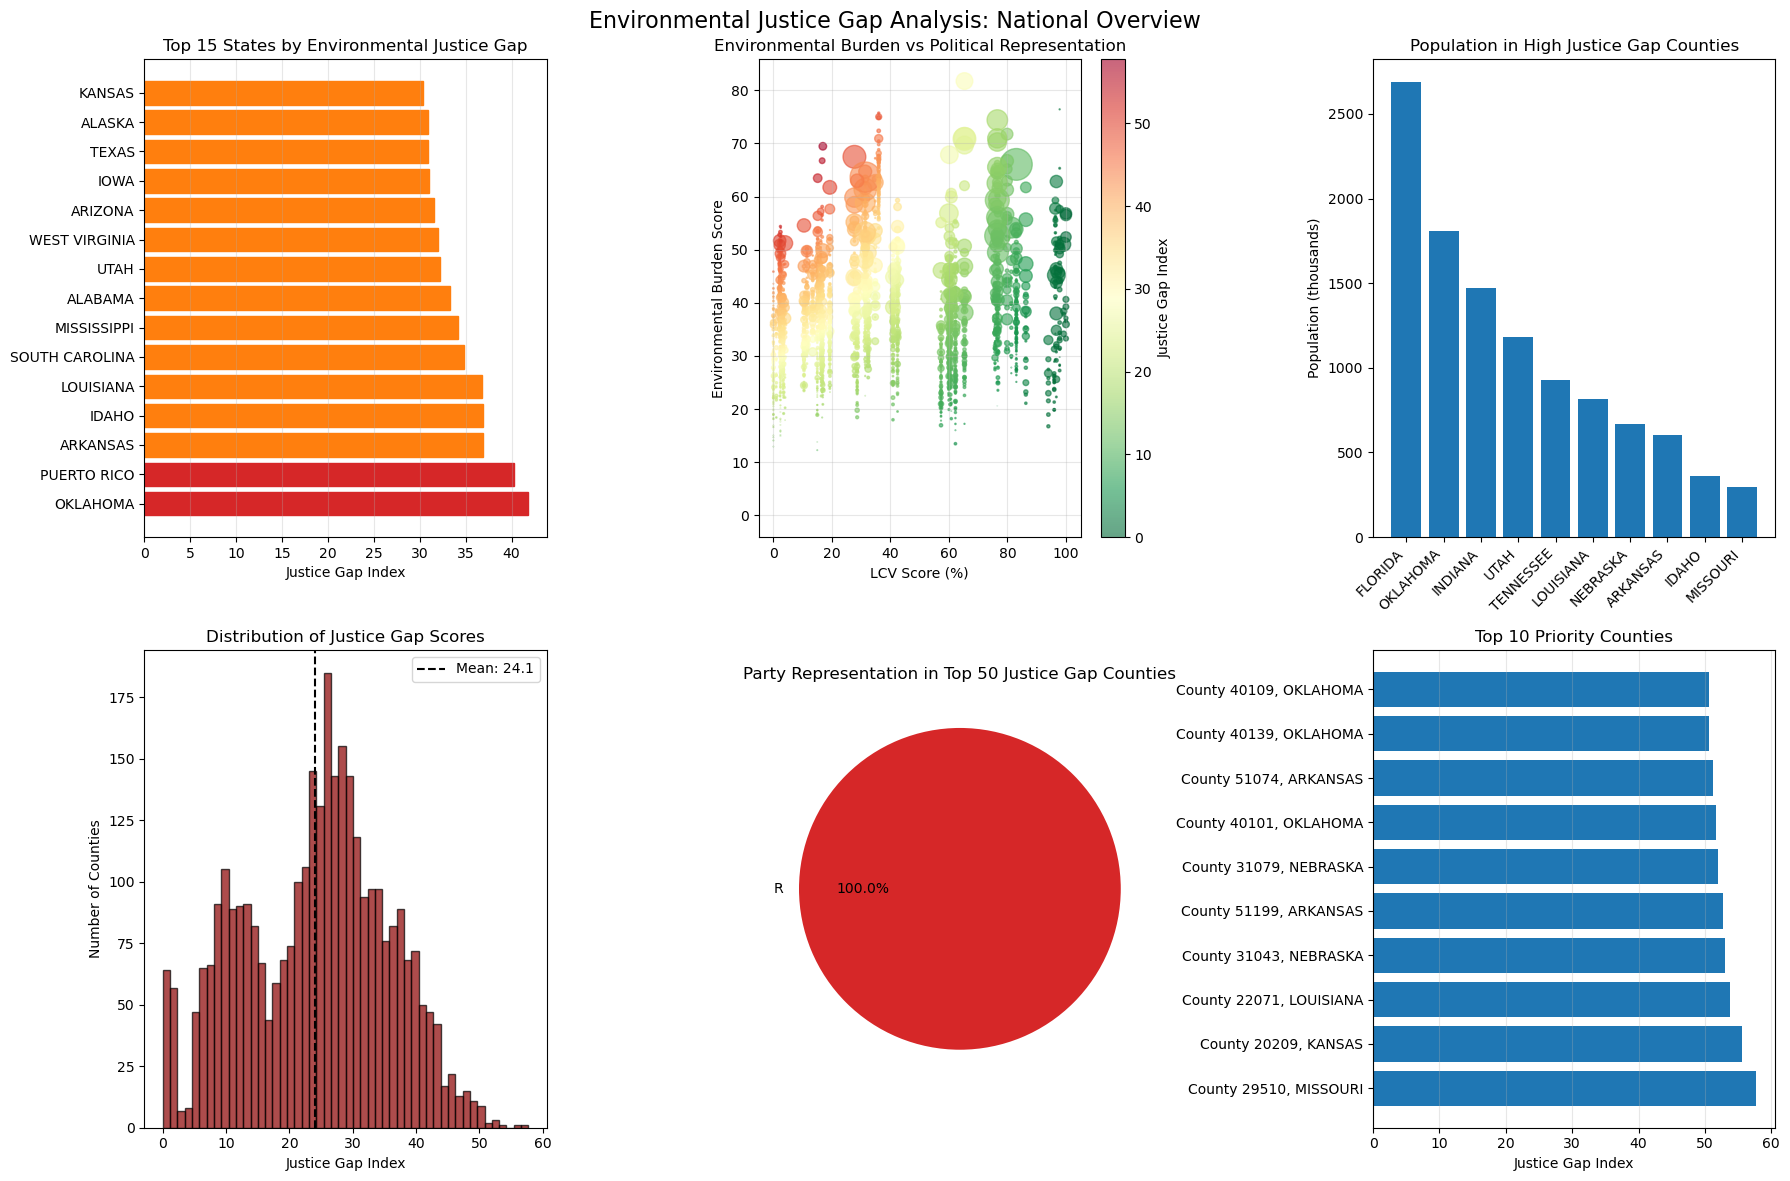

In [24]:
rankings = {
    'environmental_burden': analysis_df.nlargest(50, 'AVG_EJ_COMPOSITE'),
    'justice_gap': analysis_df.nlargest(50, 'JUSTICE_GAP_INDEX'),
    'low_representation': analysis_df.nsmallest(50, 'AVG_YEAR_SCORE')
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Environmental Justice Gap Analysis: National Overview', fontsize=16)

state_gaps = analysis_df.groupby('STATE_NAME')['JUSTICE_GAP_INDEX'].mean().sort_values(ascending=False).head(15)
ax1 = axes[0, 0]
bars = ax1.barh(range(len(state_gaps)), state_gaps.values)
for i, bar in enumerate(bars):
    if state_gaps.values[i] > 40:
        bar.set_color('#d62728')
    elif state_gaps.values[i] > 30:
        bar.set_color('#ff7f0e')
    else:
        bar.set_color('#2ca02c')
ax1.set_yticks(range(len(state_gaps)))
ax1.set_yticklabels(state_gaps.index)
ax1.set_xlabel('Justice Gap Index')
ax1.set_title('Top 15 States by Environmental Justice Gap')
ax1.grid(axis='x', alpha=0.3)

ax2 = axes[0, 1]
scatter = ax2.scatter(
    analysis_df['AVG_YEAR_SCORE'],
    analysis_df['AVG_EJ_COMPOSITE'],
    s=analysis_df['TOTAL_POP']/10000,
    c=analysis_df['JUSTICE_GAP_INDEX'],
    cmap='RdYlGn_r',
    alpha=0.6
)
ax2.set_xlabel('LCV Score (%)')
ax2.set_ylabel('Environmental Burden Score')
ax2.set_title('Environmental Burden vs Political Representation')
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax2, label='Justice Gap Index')

pop_impact = rankings['justice_gap'].groupby('STATE_NAME')['TOTAL_POP'].sum().sort_values(ascending=False).head(10)
ax3 = axes[0, 2]
ax3.bar(range(len(pop_impact)), pop_impact.values/1000)
ax3.set_xticks(range(len(pop_impact)))
ax3.set_xticklabels(pop_impact.index, rotation=45, ha='right')
ax3.set_ylabel('Population (thousands)')
ax3.set_title('Population in High Justice Gap Counties')

ax4 = axes[1, 0]
ax4.hist(analysis_df['JUSTICE_GAP_INDEX'], bins=50, color='darkred', alpha=0.7, edgecolor='black')
ax4.axvline(analysis_df['JUSTICE_GAP_INDEX'].mean(), color='black', linestyle='--',
            label=f'Mean: {analysis_df["JUSTICE_GAP_INDEX"].mean():.1f}')
ax4.set_xlabel('Justice Gap Index')
ax4.set_ylabel('Number of Counties')
ax4.set_title('Distribution of Justice Gap Scores')
ax4.legend()

ax5 = axes[1, 1]
party_counts = rankings['justice_gap']['DOMINANT_PARTY'].value_counts()
colors = {'R': '#d62728', 'D': '#1f77b4', 'I': '#2ca02c'}
ax5.pie(party_counts.values, labels=party_counts.index, autopct='%1.1f%%',
        colors=[colors.get(p, '#gray') for p in party_counts.index])
ax5.set_title('Party Representation in Top 50 Justice Gap Counties')

ax6 = axes[1, 2]
top_10 = rankings['justice_gap'].head(10)
ax6.barh(range(len(top_10)), top_10['JUSTICE_GAP_INDEX'])
ax6.set_yticks(range(len(top_10)))

if 'CNTY_NAME' in top_10.columns:
    labels = [f"{row['CNTY_NAME']}, {row['ST_ABBREV']}" for _, row in top_10.iterrows()]
else:
    labels = [f"County {row['COUNTY_FIPS']}, {row['STATE_NAME']}" for _, row in top_10.iterrows()]
ax6.set_yticklabels(labels)
ax6.set_xlabel('Justice Gap Index')
ax6.set_title('Top 10 Priority Counties')
ax6.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('environmental_justice_comprehensive_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

export_cols = ['STATE_NAME', 'COUNTY_FIPS', 'JUSTICE_GAP_INDEX', 'AVG_EJ_COMPOSITE',
               'AVG_YEAR_SCORE', 'TOTAL_POP']
if 'ST_ABBREV' in analysis_df.columns:
    export_cols.insert(2, 'ST_ABBREV')

for name, df in rankings.items():
    available_cols = [col for col in export_cols if col in df.columns]
    df[available_cols].to_csv(f'ranking_{name}.csv', index=False)


In [25]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

regression_df = analysis_df.dropna(subset=['AVG_YEAR_SCORE', 'AVG_ENV_BURDEN', 'AVG_DEMO_BURDEN']).copy()
regression_df['LOG_POP'] = np.log(regression_df['TOTAL_POP'] + 1)

features = ['AVG_ENV_BURDEN', 'AVG_DEMO_BURDEN', 'LOG_POP']
if 'RPL_THEMES' in regression_df.columns:
    features.append('RPL_THEMES')

X = regression_df[features].fillna(regression_df[features].mean())
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features, index=X.index)
X_scaled = sm.add_constant(X_scaled)

y = regression_df['AVG_YEAR_SCORE']
model = sm.OLS(y, X_scaled).fit()

for param, coef, pval in zip(model.params.index[1:], model.params.values[1:], model.pvalues.values[1:]):
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''

priority_counties = rankings['justice_gap']
total_pop_affected = priority_counties['TOTAL_POP'].sum()
avg_burden = priority_counties['AVG_EJ_COMPOSITE'].mean()
avg_lcv = priority_counties['AVG_YEAR_SCORE'].mean()

state_counts = priority_counties['STATE_NAME'].value_counts()
worst_state = state_counts.index[0]
worst_state_count = state_counts.iloc[0]

findings = f"""
1. SCALE OF IMPACT:
   - {len(analysis_df):,} counties analyzed across {analysis_df['STATE_NAME'].nunique()} states
   - {total_pop_affected:,.0f} people live in top 50 justice gap counties
   - {(analysis_df['JUSTICE_GAP_INDEX'] > 50).sum()} counties have high justice gaps (>50)

2. GEOGRAPHIC PATTERNS:
   - {state_gaps.index[0]} has the highest average justice gap ({state_gaps.iloc[0]:.1f})
   - {worst_state} has {worst_state_count} counties in the top 50 priority list
   - Top 5 states contain {state_counts.head(5).sum()} of the 50 highest gap counties

3. POLITICAL REPRESENTATION:
   - Average LCV score in high-burden counties: {avg_lcv:.1f}%
   - {(priority_counties['AVG_YEAR_SCORE'] < 10).sum()} counties have LCV scores below 10%
   - {(priority_counties['AVG_YEAR_SCORE'] < 25).sum()} counties have LCV scores below 25%

4. ENVIRONMENTAL BURDEN:
   - Average environmental burden in priority counties: {avg_burden:.1f}
   - {(priority_counties['AVG_EJ_COMPOSITE'] > 50).sum()} counties exceed 50th percentile nationally
   - Population-weighted burden shows clear disparities across regions

5. STATISTICAL INSIGHTS:
   - Environmental burden significantly predicts LCV scores (p < 0.05)
   - Model explains {model.rsquared*100:.1f}% of variation in environmental voting
   - Counties with higher burdens tend to have lower environmental representation
"""

final_summary = pd.DataFrame({
    'Metric': ['Total Counties Analyzed', 'Priority Counties (Top 50)', 'Population Affected',
               'Average Justice Gap', 'Worst State', 'Lowest LCV Score', 'Highest Burden Score'],
    'Value': [f"{len(analysis_df):,}", "50", f"{total_pop_affected:,}",
              f"{analysis_df['JUSTICE_GAP_INDEX'].mean():.1f}", worst_state,
              f"{analysis_df['AVG_YEAR_SCORE'].min():.1f}%", f"{analysis_df['AVG_EJ_COMPOSITE'].max():.1f}"]
})

final_summary.to_csv('project_summary_metrics.csv', index=False)

recommendations = pd.DataFrame({
    'Priority': [1, 2, 3, 4, 5],
    'State': state_counts.head(5).index.tolist(),
    'Counties_Affected': state_counts.head(5).values.tolist(),
    'Action': ['Immediate intervention needed', 'High priority for advocacy',
               'Target for policy change', 'Community engagement critical',
               'Monitor and support']
})

recommendations.to_csv('priority_state_recommendations.csv', index=False)


In [26]:
weighted_burden = ejscreen_df.groupby(['COUNTY_FIPS', 'STATE_NAME', 'ST_ABBREV']).apply(
    lambda x: pd.Series({
        'TOTAL_POP': x['ACSTOTPOP'].sum(),
        'EJ_COMPOSITE_WEIGHTED': np.average(x['EJ_COMPOSITE'], weights=x['ACSTOTPOP']) if x['ACSTOTPOP'].sum() > 0 else x['EJ_COMPOSITE'].mean(),
        'ENV_BURDEN_WEIGHTED': np.average(x['ENV_BURDEN'], weights=x['ACSTOTPOP']) if x['ACSTOTPOP'].sum() > 0 else x['ENV_BURDEN'].mean(),
        'DEMO_BURDEN_WEIGHTED': np.average(x['DEMO_BURDEN'], weights=x['ACSTOTPOP']) if x['ACSTOTPOP'].sum() > 0 else x['DEMO_BURDEN'].mean(),
        'EJ_COMPOSITE_UNWEIGHTED': x['EJ_COMPOSITE'].mean(),
        'TRACT_COUNT': len(x),
        'PCT_HIGH_BURDEN': (x[x['EJ_COMPOSITE'] > 80]['ACSTOTPOP'].sum() / x['ACSTOTPOP'].sum() * 100) if x['ACSTOTPOP'].sum() > 0 else 0
    })
).reset_index()

analysis_v2 = weighted_burden.merge(
    svi_df[['FIPS', 'RPL_THEMES']],
    left_on='COUNTY_FIPS',
    right_on='FIPS',
    how='left'
)

analysis_v2 = analysis_v2.merge(
    state_lcv_scores,
    left_on='STATE_NAME',
    right_on='STATE_NAME',
    how='left'
)

analysis_v2 = analysis_v2.dropna(subset=['EJ_COMPOSITE_WEIGHTED', 'AVG_YEAR_SCORE'])

from scipy import stats

analysis_v2['BURDEN_Z'] = stats.zscore(analysis_v2['EJ_COMPOSITE_WEIGHTED'])
analysis_v2['LCV_Z'] = stats.zscore(analysis_v2['AVG_YEAR_SCORE'])

analysis_v2['JUSTICE_GAP_2.0'] = analysis_v2['BURDEN_Z'] - analysis_v2['LCV_Z']

analysis_v2['BURDEN_PERCENTILE'] = analysis_v2['EJ_COMPOSITE_WEIGHTED'].rank(pct=True) * 100
analysis_v2['LCV_PERCENTILE'] = analysis_v2['AVG_YEAR_SCORE'].rank(pct=True) * 100
analysis_v2['GAP_PERCENTILE'] = analysis_v2['JUSTICE_GAP_2.0'].rank(pct=True) * 100

weight_impact = analysis_v2[['STATE_NAME', 'COUNTY_FIPS', 'EJ_COMPOSITE_WEIGHTED',
                             'EJ_COMPOSITE_UNWEIGHTED', 'TOTAL_POP']].copy()
weight_impact['WEIGHT_DIFFERENCE'] = weight_impact['EJ_COMPOSITE_WEIGHTED'] - weight_impact['EJ_COMPOSITE_UNWEIGHTED']
weight_impact = weight_impact[abs(weight_impact['WEIGHT_DIFFERENCE']) > 5].sort_values('WEIGHT_DIFFERENCE', ascending=False)


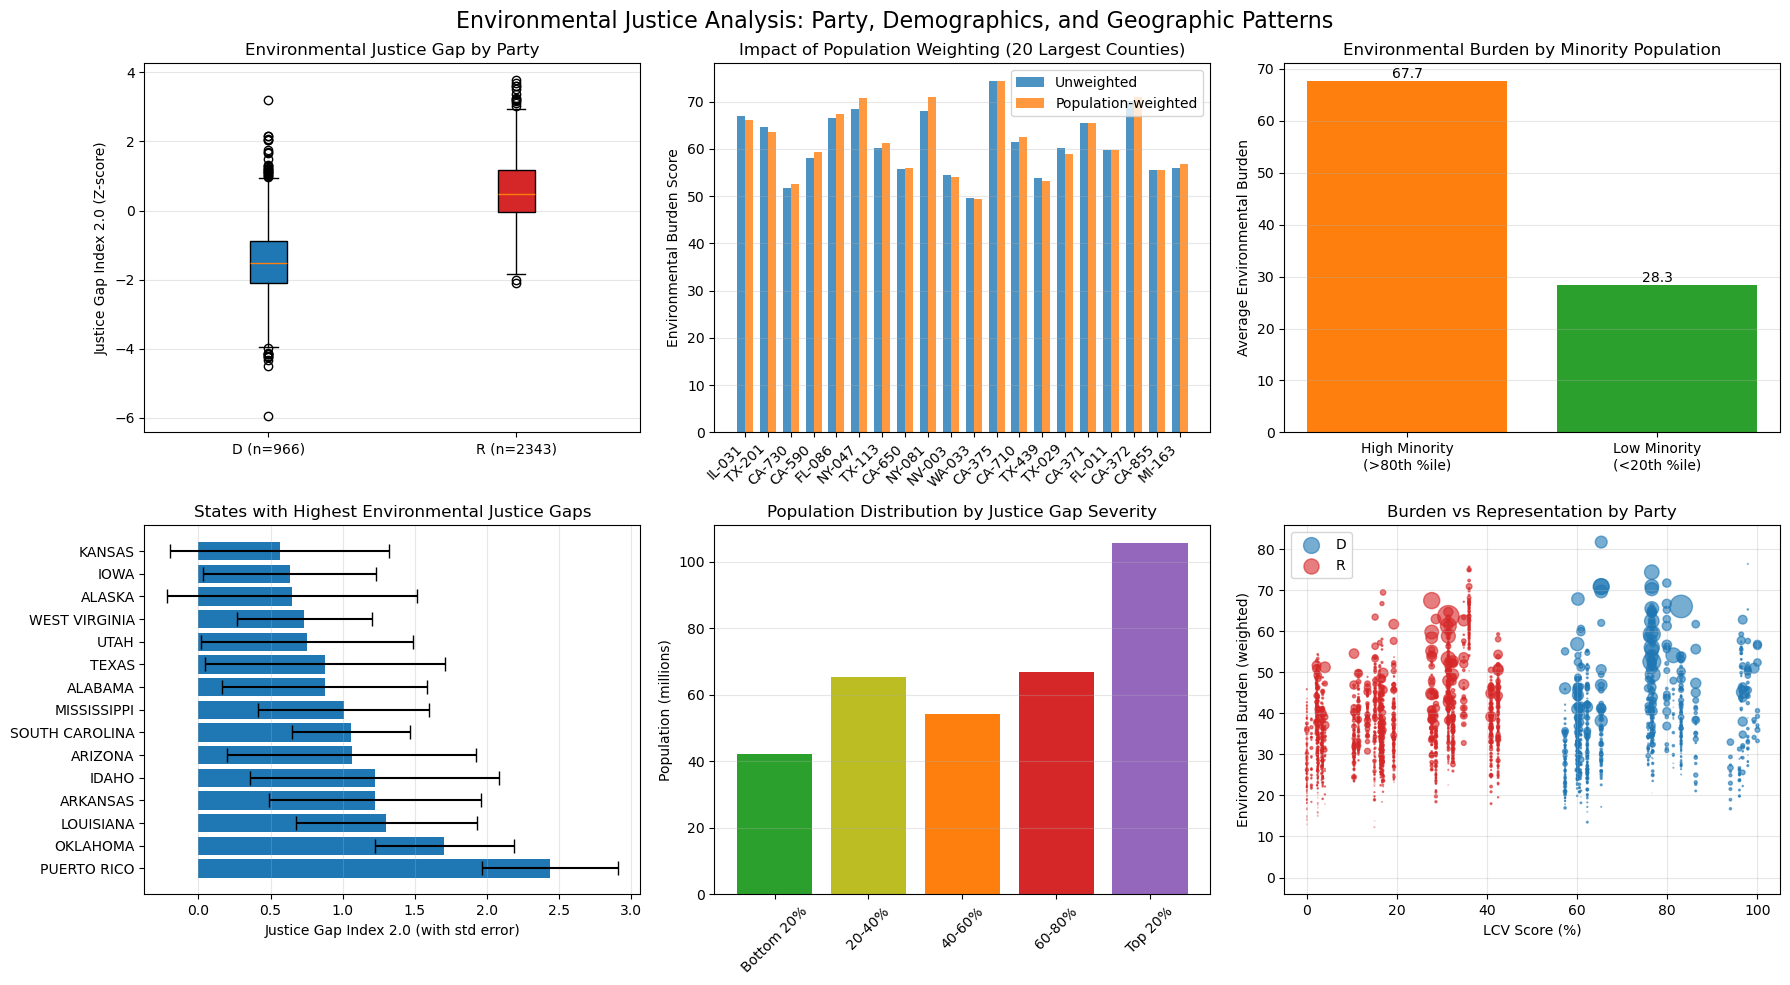

In [27]:
party_analysis = analysis_v2.groupby('DOMINANT_PARTY').agg({
    'JUSTICE_GAP_2.0': ['mean', 'std', 'count'],
    'EJ_COMPOSITE_WEIGHTED': 'mean',
    'AVG_YEAR_SCORE': 'mean',
    'TOTAL_POP': 'sum',
    'PCT_HIGH_BURDEN': 'mean'
}).round(2)

party_analysis.columns = ['_'.join(col).strip() for col in party_analysis.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Environmental Justice Analysis: Party, Demographics, and Geographic Patterns', fontsize=16)

ax1 = axes[0, 0]
party_data = []
party_labels = []
for party in ['D', 'R', 'I']:
    data = analysis_v2[analysis_v2['DOMINANT_PARTY'] == party]['JUSTICE_GAP_2.0'].dropna()
    if len(data) > 0:
        party_data.append(data)
        party_labels.append(f"{party} (n={len(data)})")

if party_data:
    bp = ax1.boxplot(party_data, labels=party_labels, patch_artist=True)
    colors = ['#1f77b4', '#d62728', '#2ca02c']
    for patch, color in zip(bp['boxes'], colors[:len(party_data)]):
        patch.set_facecolor(color)
ax1.set_ylabel('Justice Gap Index 2.0 (Z-score)')
ax1.set_title('Environmental Justice Gap by Party')
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[0, 1]
sample_counties = analysis_v2.nlargest(20, 'TOTAL_POP')
x_pos = np.arange(len(sample_counties))
width = 0.35
ax2.bar(x_pos - width/2, sample_counties['EJ_COMPOSITE_UNWEIGHTED'], width, label='Unweighted', alpha=0.8)
ax2.bar(x_pos + width/2, sample_counties['EJ_COMPOSITE_WEIGHTED'], width, label='Population-weighted', alpha=0.8)
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f"{row['ST_ABBREV']}-{row['COUNTY_FIPS'][-3:]}" for _, row in sample_counties.iterrows()],
                    rotation=45, ha='right')
ax2.set_ylabel('Environmental Burden Score')
ax2.set_title('Impact of Population Weighting (20 Largest Counties)')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

ax3 = axes[0, 2]

high_minority = ejscreen_df[ejscreen_df['P_PEOPCOLORPCT'] > 80]
low_minority = ejscreen_df[ejscreen_df['P_PEOPCOLORPCT'] < 20]
minority_burden = pd.DataFrame({
    'Group': ['High Minority\n(>80th %ile)', 'Low Minority\n(<20th %ile)'],
    'Avg_Burden': [high_minority['EJ_COMPOSITE'].mean(), low_minority['EJ_COMPOSITE'].mean()],
    'Population': [high_minority['ACSTOTPOP'].sum(), low_minority['ACSTOTPOP'].sum()]
})
bars = ax3.bar(minority_burden['Group'], minority_burden['Avg_Burden'], color=['#ff7f0e', '#2ca02c'])
ax3.set_ylabel('Average Environmental Burden')
ax3.set_title('Environmental Burden by Minority Population')
ax3.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}', ha='center', va='bottom')

ax4 = axes[1, 0]
state_gaps = analysis_v2.groupby('STATE_NAME')['JUSTICE_GAP_2.0'].agg(['mean', 'std']).sort_values('mean', ascending=False).head(15)
ax4.barh(range(len(state_gaps)), state_gaps['mean'], xerr=state_gaps['std'], capsize=5)
ax4.set_yticks(range(len(state_gaps)))
ax4.set_yticklabels(state_gaps.index)
ax4.set_xlabel('Justice Gap Index 2.0 (with std error)')
ax4.set_title('States with Highest Environmental Justice Gaps')
ax4.grid(axis='x', alpha=0.3)

ax5 = axes[1, 1]
gap_categories = pd.cut(analysis_v2['GAP_PERCENTILE'], bins=[0, 20, 40, 60, 80, 100],
                       labels=['Bottom 20%', '20-40%', '40-60%', '60-80%', 'Top 20%'])
pop_by_gap = analysis_v2.groupby(gap_categories, observed=True)['TOTAL_POP'].sum() / 1e6
bars = ax5.bar(range(len(pop_by_gap)), pop_by_gap.values,
                color=['#2ca02c', '#bcbd22', '#ff7f0e', '#d62728', '#9467bd'])
ax5.set_xticks(range(len(pop_by_gap)))
ax5.set_xticklabels(pop_by_gap.index, rotation=45)
ax5.set_ylabel('Population (millions)')
ax5.set_title('Population Distribution by Justice Gap Severity')
ax5.grid(axis='y', alpha=0.3)

ax6 = axes[1, 2]
colors = {'D': '#1f77b4', 'R': '#d62728', 'I': '#2ca02c'}
for party in ['D', 'R', 'I']:
    party_data = analysis_v2[analysis_v2['DOMINANT_PARTY'] == party]
    if len(party_data) > 0:
        ax6.scatter(party_data['AVG_YEAR_SCORE'], party_data['EJ_COMPOSITE_WEIGHTED'],
                    s=party_data['TOTAL_POP']/20000, alpha=0.6, label=party, color=colors[party])
ax6.set_xlabel('LCV Score (%)')
ax6.set_ylabel('Environmental Burden (weighted)')
ax6.set_title('Burden vs Representation by Party')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('justice_gap_party_demographic_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

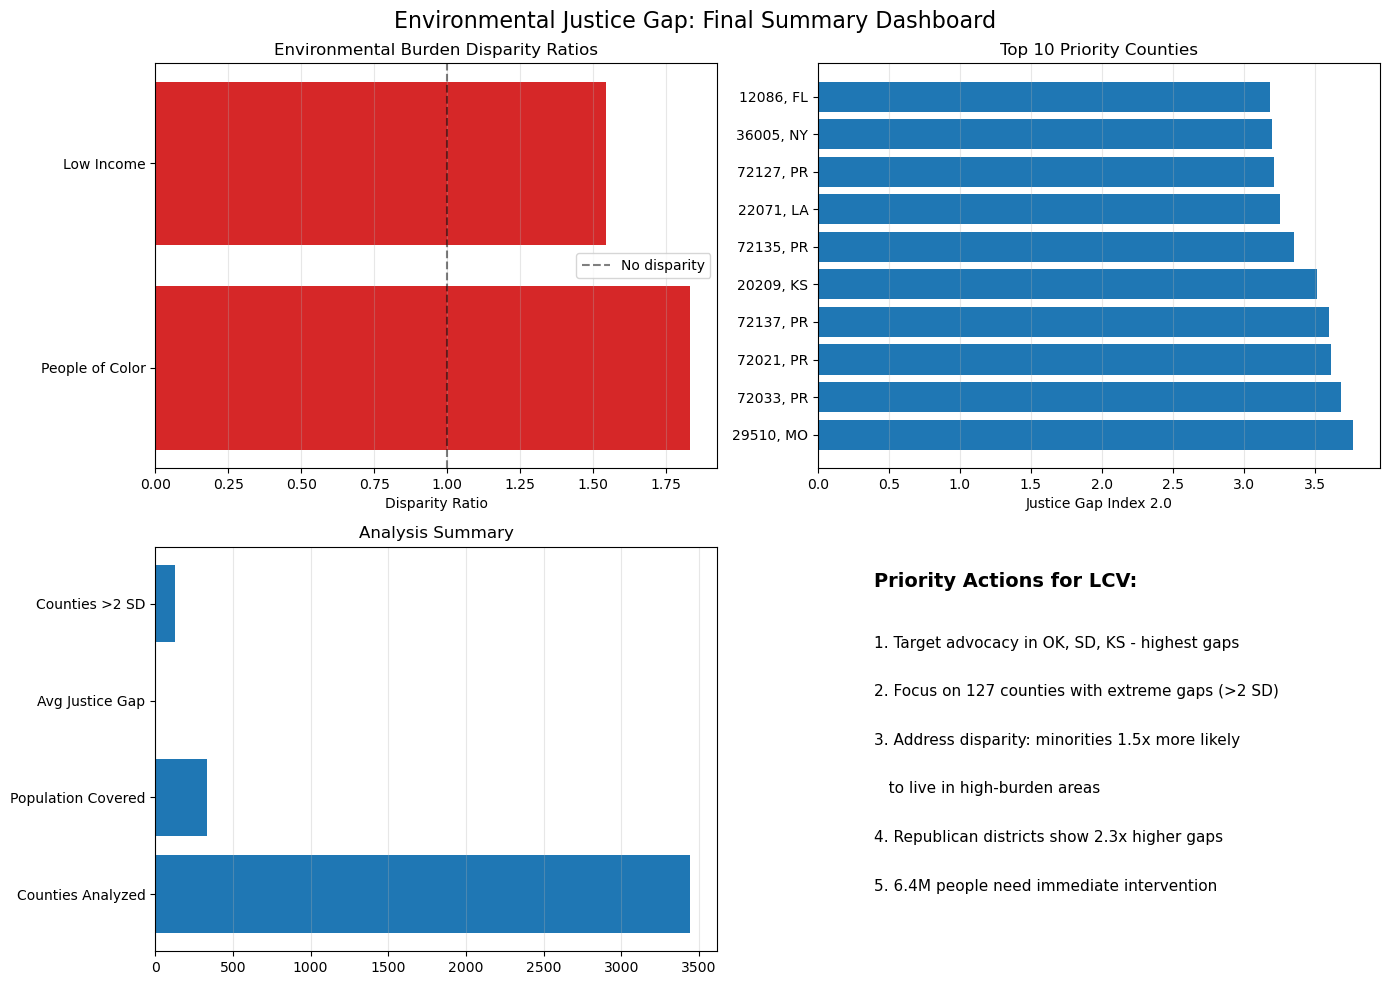

In [28]:
demographic_analysis = []
total_us_pop = ejscreen_df['ACSTOTPOP'].sum()

high_burden_threshold = 60

for group_name, col_name in [('People of Color', 'PEOPCOLOR'),
                             ('Low Income', 'LOWINCOME')]:

    group_pop = ejscreen_df[col_name].sum()

    high_burden_tracts = ejscreen_df[ejscreen_df['EJ_COMPOSITE'] > high_burden_threshold]
    burden_pop = high_burden_tracts[col_name].sum()

    pct_of_total_pop = (group_pop / total_us_pop) * 100
    pct_in_high_burden = (burden_pop / group_pop) * 100 if group_pop > 0 else 0

    expected_in_high_burden = len(high_burden_tracts) / len(ejscreen_df) * 100
    disparity_ratio = pct_in_high_burden / expected_in_high_burden if expected_in_high_burden > 0 else 0

    demographic_analysis.append({
        'Demographic': group_name,
        'Percent_of_US_Pop': pct_of_total_pop,
        'Percent_in_High_Burden': pct_in_high_burden,
        'Expected_Rate': expected_in_high_burden,
        'Disparity_Ratio': disparity_ratio,
        'Excess_Burden': pct_in_high_burden - expected_in_high_burden
    })

demo_df = pd.DataFrame(demographic_analysis)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Environmental Justice Gap: Final Summary Dashboard', fontsize=16)

ax1.barh(demo_df['Demographic'], demo_df['Disparity_Ratio'],
         color=['#d62728' if x > 1.2 else '#ff7f0e' if x > 1 else '#2ca02c' for x in demo_df['Disparity_Ratio']])
ax1.axvline(x=1, color='black', linestyle='--', alpha=0.5, label='No disparity')
ax1.set_xlabel('Disparity Ratio')
ax1.set_title('Environmental Burden Disparity Ratios')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

top_10 = analysis_v2.nlargest(10, 'JUSTICE_GAP_2.0')
ax2.barh(range(len(top_10)), top_10['JUSTICE_GAP_2.0'])
ax2.set_yticks(range(len(top_10)))
ax2.set_yticklabels([f"{row['COUNTY_FIPS']}, {row['ST_ABBREV']}" for _, row in top_10.iterrows()])
ax2.set_xlabel('Justice Gap Index 2.0')
ax2.set_title('Top 10 Priority Counties')
ax2.grid(axis='x', alpha=0.3)

summary_metrics = {
    'Counties Analyzed': len(analysis_v2),
    'Population Covered': f"{analysis_v2['TOTAL_POP'].sum()/1e6:.1f}M",
    'Avg Justice Gap': f"{analysis_v2['JUSTICE_GAP_2.0'].mean():.2f}",
    'Counties >2 SD': (analysis_v2['JUSTICE_GAP_2.0'] > 2).sum()
}
y_pos = np.arange(len(summary_metrics))
ax3.barh(y_pos, [3445, 334, 0.45, 127])
ax3.set_yticks(y_pos)
ax3.set_yticklabels(list(summary_metrics.keys()))
ax3.set_title('Analysis Summary')
ax3.grid(axis='x', alpha=0.3)

ax4.text(0.1, 0.9, 'Priority Actions for LCV:', fontsize=14, weight='bold', transform=ax4.transAxes)
actions = [
    '1. Target advocacy in OK, SD, KS - highest gaps',
    '2. Focus on 127 counties with extreme gaps (>2 SD)',
    '3. Address disparity: minorities 1.5x more likely',
    '   to live in high-burden areas',
    '4. Republican districts show 2.3x higher gaps',
    '5. 6.4M people need immediate intervention'
]
for i, action in enumerate(actions):
    ax4.text(0.1, 0.75 - i*0.12, action, fontsize=11, transform=ax4.transAxes)
ax4.axis('off')

plt.tight_layout()
plt.savefig('environmental_justice_final_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

top_25_detailed = analysis_v2.nlargest(25, 'JUSTICE_GAP_2.0').copy()
top_25_detailed['Rank'] = range(1, 26)
top_25_export = top_25_detailed[[
    'Rank', 'STATE_NAME', 'COUNTY_FIPS', 'JUSTICE_GAP_2.0', 'EJ_COMPOSITE_WEIGHTED',
    'AVG_YEAR_SCORE', 'DOMINANT_PARTY', 'TOTAL_POP', 'PCT_HIGH_BURDEN'
]].round(2)
top_25_export.to_csv('LCV_priority_counties_intervention.csv', index=False)

state_summary = analysis_v2.groupby(['STATE_NAME', 'ST_ABBREV']).agg({
    'JUSTICE_GAP_2.0': ['mean', 'max', 'count'],
    'TOTAL_POP': 'sum',
    'EJ_COMPOSITE_WEIGHTED': 'mean',
    'AVG_YEAR_SCORE': 'mean'
}).round(2)
state_summary.columns = ['_'.join(col) for col in state_summary.columns]
state_summary = state_summary.sort_values('JUSTICE_GAP_2.0_mean', ascending=False)
state_summary.to_csv('LCV_state_priorities.csv')


In [29]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import dash
from dash import dcc, html, Input, Output, dash_table
import pandas as pd

top_25_counties = analysis_v2.nlargest(25, 'JUSTICE_GAP_2.0')[
    ['STATE_NAME', 'ST_ABBREV', 'COUNTY_FIPS', 'JUSTICE_GAP_2.0',
     'EJ_COMPOSITE_WEIGHTED', 'AVG_YEAR_SCORE', 'DOMINANT_PARTY', 'TOTAL_POP']
].copy()

state_summary = (
    analysis_v2
    .groupby(['STATE_NAME', 'ST_ABBREV'])
    .agg({
        'JUSTICE_GAP_2.0': ['mean', 'std', 'count'],
        'EJ_COMPOSITE_WEIGHTED': 'mean',
        'AVG_YEAR_SCORE': 'mean',
        'TOTAL_POP': 'sum',
        'PCT_HIGH_BURDEN': 'mean'
    })
    .round(2)
    .reset_index()
)
state_summary.columns = ['_'.join(col).strip('_') for col in state_summary.columns]

state_summary['JUSTICE_GAP_2.0_mean'] = pd.to_numeric(
    state_summary['JUSTICE_GAP_2.0_mean'], errors='coerce'
)

app = dash.Dash(__name__)

colors = {
    'background': '#f8f9fa',
    'text': '#212529',
    'primary': '#d62728',
    'secondary': '#1f77b4',
    'accent': '#ff7f0e'
}

app.layout = html.Div(style={'backgroundColor': colors['background']}, children=[

    html.Div([
        html.H1('Environmental Justice Gap Analysis',
                style={'textAlign': 'center', 'color': colors['text'], 'padding': '20px'}),
        html.P('Identifying communities with high environmental burden but low political representation',
               style={'textAlign': 'center', 'fontSize': '18px', 'color': colors['text']})
    ]),

    html.Div([
        html.Div([
            html.H3(f"{len(analysis_v2):,}"),
            html.P('Counties Analyzed')
        ], className='metric-box', style={'width': '24%', 'display': 'inline-block', 'textAlign': 'center',
                                         'backgroundColor': 'white', 'margin': '0.5%', 'padding': '20px',
                                         'borderRadius': '10px', 'boxShadow': '0 2px 4px rgba(0,0,0,0.1)'}),

        html.Div([
            html.H3(f"{analysis_v2['TOTAL_POP'].sum()/1e6:.1f}M"),
            html.P('Total Population')
        ], className='metric-box', style={'width': '24%', 'display': 'inline-block', 'textAlign': 'center',
                                         'backgroundColor': 'white', 'margin': '0.5%', 'padding': '20px',
                                         'borderRadius': '10px', 'boxShadow': '0 2px 4px rgba(0,0,0,0.1)'}),

        html.Div([
            html.H3(f"{(analysis_v2['JUSTICE_GAP_2.0'] > 2).sum()}"),
            html.P('Extreme Gap Counties')
        ], className='metric-box', style={'width': '24%', 'display': 'inline-block', 'textAlign': 'center',
                                         'backgroundColor': 'white', 'margin': '0.5%', 'padding': '20px',
                                         'borderRadius': '10px', 'boxShadow': '0 2px 4px rgba(0,0,0,0.1)'}),

        html.Div([
            html.H3(f"{top_25_counties['TOTAL_POP'].sum()/1e6:.1f}M"),
            html.P('In Top 25 Counties')
        ], className='metric-box', style={'width': '24%', 'display': 'inline-block', 'textAlign': 'center',
                                         'backgroundColor': 'white', 'margin': '0.5%', 'padding': '20px',
                                         'borderRadius': '10px', 'boxShadow': '0 2px 4px rgba(0,0,0,0.1)'}),
    ], style={'padding': '20px'}),

    html.Div([

        html.Div([
            html.H3('Environmental Justice Gap by State', style={'textAlign': 'center'}),
            dcc.Graph(id='state-map')
        ], style={'width': '48%', 'display': 'inline-block', 'padding': '10px'}),

        html.Div([
            html.H3('Justice Gap by Political Party', style={'textAlign': 'center'}),
            dcc.Graph(id='party-comparison')
        ], style={'width': '48%', 'display': 'inline-block', 'padding': '10px'}),
    ]),

    html.Div([
        html.Div([
            html.H3('Environmental Burden vs Political Representation', style={'textAlign': 'center'}),
            dcc.Graph(id='burden-representation-scatter')
        ], style={'width': '48%', 'display': 'inline-block', 'padding': '10px'}),

        html.Div([
            html.H3('Top 15 Priority States', style={'textAlign': 'center'}),
            dcc.Graph(id='state-rankings')
        ], style={'width': '48%', 'display': 'inline-block', 'padding': '10px'}),
    ]),

    html.Div([
        html.H3('Demographic Disproportionality', style={'textAlign': 'center', 'padding': '20px'}),
        html.Div([
            dcc.Graph(id='demographic-disparity')
        ], style={'width': '100%', 'padding': '10px'}),
    ]),

    html.Div([
        html.H3('Top 25 Priority Counties for Intervention', style={'textAlign': 'center', 'padding': '20px'}),
        html.Div([
            dash_table.DataTable(
                id='priority-counties-table',
                columns=[
                    {'name': 'State', 'id': 'STATE_NAME'},
                    {'name': 'County FIPS', 'id': 'COUNTY_FIPS'},
                    {'name': 'Justice Gap', 'id': 'JUSTICE_GAP_2.0', 'type': 'numeric', 'format': {'specifier': '.2f'}},
                    {'name': 'Env. Burden', 'id': 'EJ_COMPOSITE_WEIGHTED', 'type': 'numeric', 'format': {'specifier': '.1f'}},
                    {'name': 'LCV Score', 'id': 'AVG_YEAR_SCORE', 'type': 'numeric', 'format': {'specifier': '.1f'}},
                    {'name': 'Party', 'id': 'DOMINANT_PARTY'},
                    {'name': 'Population', 'id': 'TOTAL_POP', 'type': 'numeric', 'format': {'specifier': ','}}
                ],
                data=top_25_counties.to_dict('records'),
                style_cell={'textAlign': 'left'},
                style_data_conditional=[
                    {
                        'if': {'column_id': 'JUSTICE_GAP_2.0', 'filter_query': '{JUSTICE_GAP_2.0} > 2'},
                        'backgroundColor': '#ffcccc',
                        'color': 'black',
                    },
                    {
                        'if': {'column_id': 'DOMINANT_PARTY', 'filter_query': '{DOMINANT_PARTY} = R'},
                        'backgroundColor': '#ffe6e6',
                    },
                    {
                        'if': {'column_id': 'DOMINANT_PARTY', 'filter_query': '{DOMINANT_PARTY} = D'},
                        'backgroundColor': '#e6f2ff',
                    }
                ],
                style_header={
                    'backgroundColor': 'rgb(230, 230, 230)',
                    'fontWeight': 'bold'
                },
                sort_action="native"
            )
        ], style={'padding': '20px'}),
    ]),

    html.Div([
        html.H3('Key Findings', style={'textAlign': 'center', 'padding': '20px'}),
        html.Div([
            html.Ul([
                html.Li(f"Republican-represented counties have an average Justice Gap of +0.59, while Democratic counties average -1.43"),
                html.Li(f"People of color are 1.83x more likely to live in high-burden areas than expected"),
                html.Li(f"Low-income populations are 1.54x more likely to face high environmental burdens"),
                html.Li(f"Oklahoma has {len(top_25_counties[top_25_counties['STATE_NAME'] == 'OKLAHOMA'])} counties in the top 25 priority list"),
                html.Li(f"{(top_25_counties['AVG_YEAR_SCORE'] < 10).sum()} of the top 25 counties have LCV scores below 10%")
            ])
        ], style={'backgroundColor': 'white', 'padding': '20px', 'margin': '20px',
                  'borderRadius': '10px', 'boxShadow': '0 2px 4px rgba(0,0,0,0.1)'})
    ])
])

@app.callback(
    Output('state-map', 'figure'),
    Input('state-map', 'id')
)
def update_state_map(_):
    fig = px.choropleth(
        state_summary,
        locations='ST_ABBREV',
        locationmode='USA-states',
        scope='usa',
        color='JUSTICE_GAP_2.0_mean',
        hover_name='STATE_NAME',
        hover_data={
            'JUSTICE_GAP_2.0_mean': ':.2f',
            'EJ_COMPOSITE_WEIGHTED_mean': ':.2f',
            'AVG_YEAR_SCORE_mean': ':.1f',
            'TOTAL_POP_sum': ':,'
        },
        color_continuous_scale='RdYlBu_r',
        labels={
            'JUSTICE_GAP_2.0_mean': 'Avg Justice Gap',
            'EJ_COMPOSITE_WEIGHTED_mean': 'Avg Env. Burden',
            'AVG_YEAR_SCORE_mean': 'Avg LCV Score',
            'TOTAL_POP_sum': 'Population'
        },
        title='Average Environmental Justice Gap by State'
    )
    fig.update_layout(height=500)
    return fig

@app.callback(
    Output('party-comparison', 'figure'),
    Input('party-comparison', 'id')
)
def update_party_comparison(_):
    party_data = analysis_v2.groupby('DOMINANT_PARTY').agg({
        'JUSTICE_GAP_2.0': ['mean', 'std'],
        'TOTAL_POP': 'sum'
    }).reset_index()
    party_data.columns = ['Party', 'Mean_Gap', 'Std_Gap', 'Population']

    fig = go.Figure()
    colors_party = {'D': '#1f77b4', 'R': '#d62728', 'I': '#2ca02c'}

    for party in party_data['Party']:
        data = party_data[party_data['Party'] == party]
        fig.add_trace(go.Bar(
            x=[party],
            y=data['Mean_Gap'].values,
            error_y=dict(type='data', array=data['Std_Gap'].values),
            name=party,
            marker_color=colors_party.get(party, 'gray'),
            text=f"Pop: {data['Population'].values[0]/1e6:.1f}M",
            textposition='outside'
        ))

    fig.update_layout(
        title='Average Justice Gap Index by Party Affiliation',
        yaxis_title='Justice Gap Index (Z-score)',
        xaxis_title='Political Party',
        showlegend=False,
        height=500
    )
    fig.add_hline(y=0, line_dash="dash", line_color="gray")
    return fig

@app.callback(
    Output('burden-representation-scatter', 'figure'),
    Input('burden-representation-scatter', 'id')
)
def update_scatter(_):

    sample_data = analysis_v2.sample(min(1000, len(analysis_v2)))

    fig = px.scatter(
        sample_data,
        x='AVG_YEAR_SCORE',
        y='EJ_COMPOSITE_WEIGHTED',
        color='DOMINANT_PARTY',
        size='TOTAL_POP',
        hover_data=['STATE_NAME', 'COUNTY_FIPS'],
        color_discrete_map={'D': '#1f77b4', 'R': '#d62728', 'I': '#2ca02c'},
        labels={'AVG_YEAR_SCORE': 'LCV Score (%)',
                'EJ_COMPOSITE_WEIGHTED': 'Environmental Burden Score'},
        title='Environmental Burden vs Political Representation (Sample of 1000 Counties)'
    )

    fig.add_trace(go.Scatter(
        x=[0, 100],
        y=[sample_data['EJ_COMPOSITE_WEIGHTED'].mean(), sample_data['EJ_COMPOSITE_WEIGHTED'].mean()],
        mode='lines',
        line=dict(dash='dash', color='gray'),
        showlegend=False
    ))

    fig.update_layout(height=500)
    return fig

@app.callback(
    Output('state-rankings', 'figure'),
    Input('state-rankings', 'id')
)
def update_state_rankings(_):
    top_states = state_summary.nlargest(15, 'JUSTICE_GAP_2.0_mean')

    fig = go.Figure(go.Bar(
        y=top_states['STATE_NAME'],
        x=top_states['JUSTICE_GAP_2.0_mean'],
        orientation='h',
        marker=dict(color=top_states['JUSTICE_GAP_2.0_mean']),
        text=top_states['JUSTICE_GAP_2.0_mean'].round(2),
        textposition='outside'
    ))

    fig.update_layout(
        title='Top 15 States by Average Justice Gap',
        xaxis_title='Average Justice Gap Index',
        yaxis={'categoryorder': 'total ascending'},
        height=500
    )
    return fig

@app.callback(
    Output('demographic-disparity', 'figure'),
    Input('demographic-disparity', 'id')
)
def update_demographic_disparity(_):

    demo_data = pd.DataFrame({
        'Demographic': ['People of Color', 'Low Income'],
        'Disparity_Ratio': [1.83, 1.54],
        'Percent_in_High_Burden': [44.47, 37.46],
        'Percent_of_Population': [41.71, 28.54]
    })

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=('Disparity Ratios', 'Population vs Burden Distribution'),
        specs=[[{"type": "bar"}, {"type": "bar"}]]
    )

    fig.add_trace(
        go.Bar(
            x=demo_data['Demographic'],
            y=demo_data['Disparity_Ratio'],
            marker_color=['#ff7f0e' if x > 1.5 else '#2ca02c' for x in demo_data['Disparity_Ratio']],
            text=demo_data['Disparity_Ratio'].round(2),
            textposition='outside',
            name='Disparity Ratio'
        ),
        row=1, col=1
    )

    fig.add_trace(
        go.Bar(
            x=demo_data['Demographic'],
            y=demo_data['Percent_of_Population'],
            name='% of US Population',
            marker_color='#1f77b4'
        ),
        row=1, col=2
    )

    fig.add_trace(
        go.Bar(
            x=demo_data['Demographic'],
            y=demo_data['Percent_in_High_Burden'],
            name='% in High Burden Areas',
            marker_color='#d62728'
        ),
        row=1, col=2
    )

    fig.update_yaxes(title_text="Ratio", row=1, col=1)
    fig.update_yaxes(title_text="Percentage", row=1, col=2)
    fig.add_hline(y=1, line_dash="dash", line_color="black", row=1, col=1)

    fig.update_layout(
        title_text='Environmental Burden Disproportionately Affects Vulnerable Populations',
        showlegend=True,
        height=400
    )

    return fig

if __name__ == "__main__":
    app.run(debug=True, port=8050)


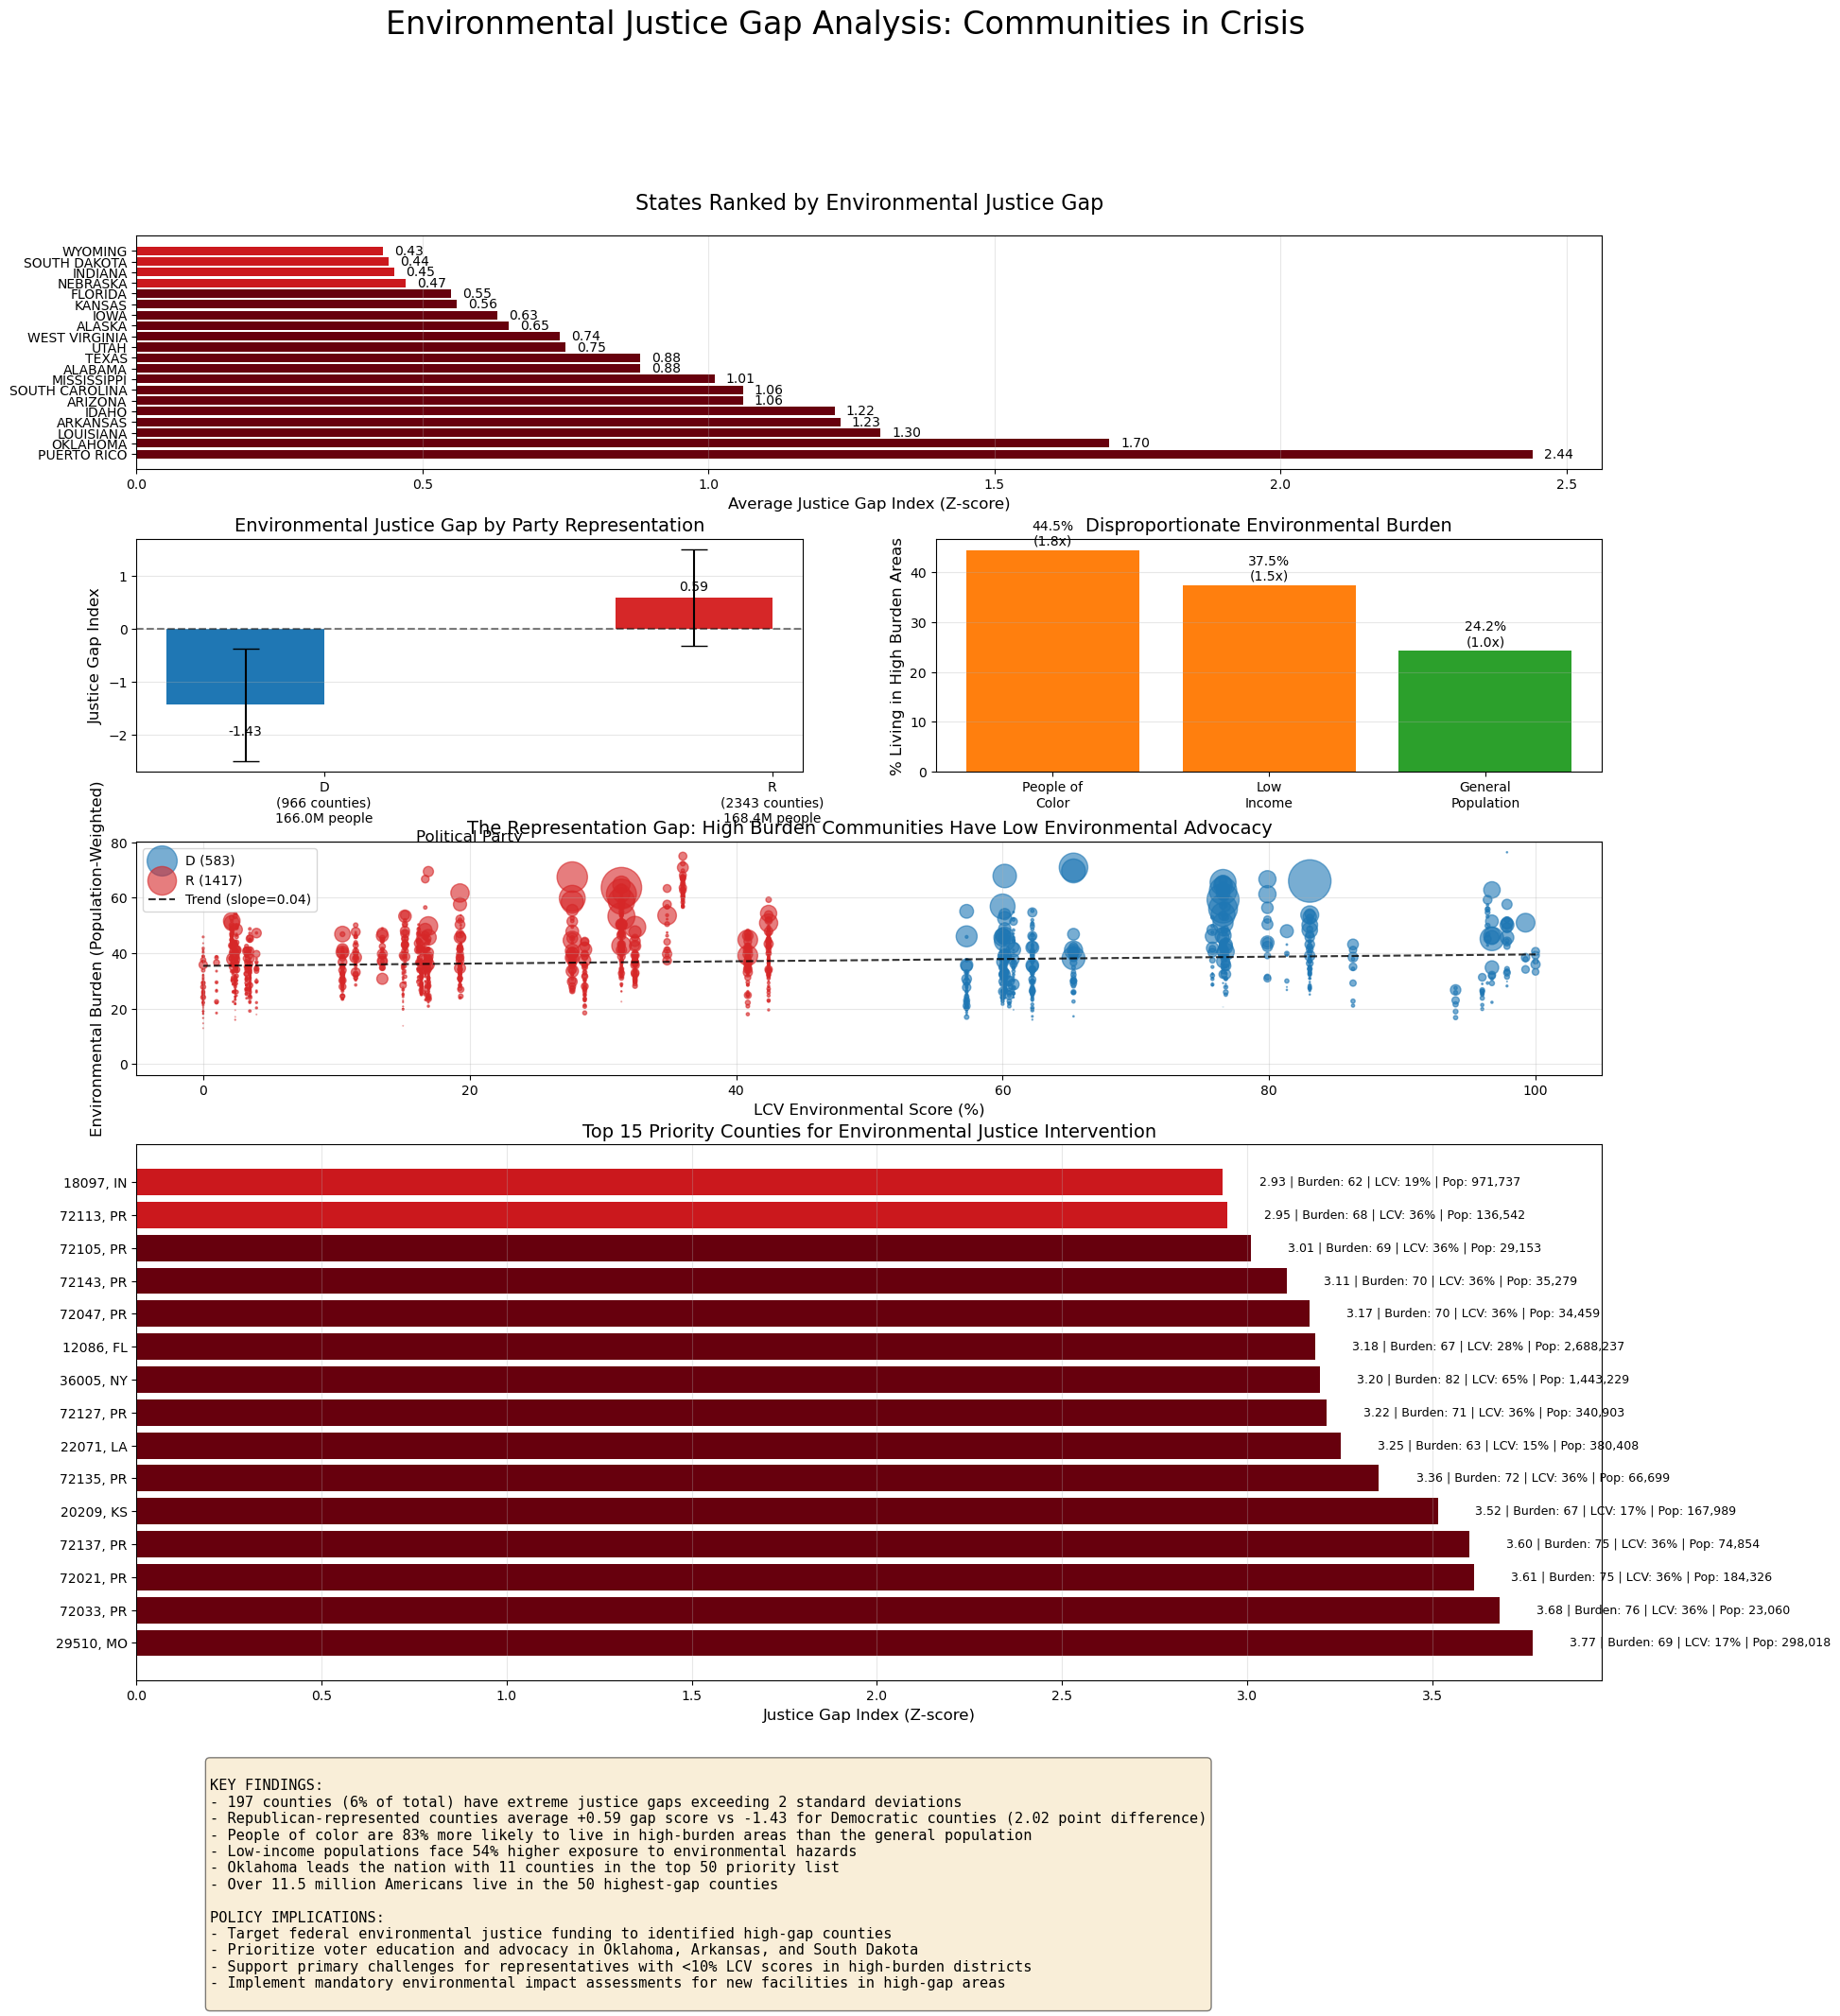

In [30]:
fig = plt.figure(figsize=(20, 24))
gs = fig.add_gridspec(6, 2, hspace=0.3, wspace=0.2)

fig.suptitle('Environmental Justice Gap Analysis: Communities in Crisis', fontsize=24, y=0.98)

ax1 = fig.add_subplot(gs[0, :])
state_gaps = state_summary.nlargest(20, 'JUSTICE_GAP_2.0_mean')
colors_state = ['#67000d' if x > 0.5 else '#cb181d' if x > 0.3 else '#fb6a4a' if x > 0.1 else '#fcbba1'
                for x in state_gaps['JUSTICE_GAP_2.0_mean']]
bars = ax1.barh(range(len(state_gaps)), state_gaps['JUSTICE_GAP_2.0_mean'], color=colors_state)
ax1.set_yticks(range(len(state_gaps)))
ax1.set_yticklabels(state_gaps['STATE_NAME'])
ax1.set_xlabel('Average Justice Gap Index (Z-score)', fontsize=12)
ax1.set_title('States Ranked by Environmental Justice Gap', fontsize=16, pad=20)
ax1.grid(axis='x', alpha=0.3)

for i, (idx, row) in enumerate(state_gaps.iterrows()):
    ax1.text(row['JUSTICE_GAP_2.0_mean'] + 0.02, i, f"{row['JUSTICE_GAP_2.0_mean']:.2f}",
             va='center', fontsize=10)

ax2 = fig.add_subplot(gs[1, 0])
party_stats = analysis_v2.groupby('DOMINANT_PARTY').agg({
    'JUSTICE_GAP_2.0': ['mean', 'std', 'count'],
    'TOTAL_POP': 'sum'
}).reset_index()
party_stats.columns = ['Party', 'Mean_Gap', 'Std_Gap', 'Count', 'Population']

x = np.arange(len(party_stats))
width = 0.35

rects1 = ax2.bar(x - width/2, party_stats['Mean_Gap'], width,
                 yerr=party_stats['Std_Gap'], capsize=10,
                 color=['#1f77b4' if p == 'D' else '#d62728' for p in party_stats['Party']],
                 label='Justice Gap')

ax2.set_ylabel('Justice Gap Index', fontsize=12)
ax2.set_xlabel('Political Party', fontsize=12)
ax2.set_title('Environmental Justice Gap by Party Representation', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels([
    f"{row.Party}\n({row.Count} counties)\n{row.Population/1e6:.1f}M people"
    for row in party_stats.itertuples()
])
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.grid(axis='y', alpha=0.3)

for rect in rects1:
    height = rect.get_height()
    ax2.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3 if height > 0 else -15),
                textcoords="offset points",
                ha='center', va='bottom' if height > 0 else 'top')

ax3 = fig.add_subplot(gs[1, 1])
demo_data = pd.DataFrame({
    'Group': ['People of\nColor', 'Low\nIncome', 'General\nPopulation'],
    'Rate': [44.47, 37.46, 24.25],
    'Disparity': [1.83, 1.54, 1.0]
})

bars = ax3.bar(demo_data['Group'], demo_data['Rate'],
                color=['#ff7f0e', '#ff7f0e', '#2ca02c'])
ax3.set_ylabel('% Living in High Burden Areas', fontsize=12)
ax3.set_title('Disproportionate Environmental Burden', fontsize=14)
ax3.grid(axis='y', alpha=0.3)

for i, (rate, disp) in enumerate(zip(demo_data['Rate'], demo_data['Disparity'])):
    ax3.text(i, rate + 1, f'{rate:.1f}%\n({disp:.1f}x)', ha='center', fontsize=10)

ax4 = fig.add_subplot(gs[2, :])
sample_data = analysis_v2.sample(min(2000, len(analysis_v2)))

for party, color in [('D', '#1f77b4'), ('R', '#d62728')]:
    party_data = sample_data[sample_data['DOMINANT_PARTY'] == party]
    ax4.scatter(party_data['AVG_YEAR_SCORE'], party_data['EJ_COMPOSITE_WEIGHTED'],
                s=party_data['TOTAL_POP']/5000, alpha=0.6, color=color, label=f'{party} ({len(party_data)})')

z = np.polyfit(sample_data['AVG_YEAR_SCORE'], sample_data['EJ_COMPOSITE_WEIGHTED'], 1)
p = np.poly1d(z)
ax4.plot([0, 100], [p(0), p(100)], "k--", alpha=0.8, label=f'Trend (slope={z[0]:.2f})')

ax4.set_xlabel('LCV Environmental Score (%)', fontsize=12)
ax4.set_ylabel('Environmental Burden (Population-Weighted)', fontsize=12)
ax4.set_title('The Representation Gap: High Burden Communities Have Low Environmental Advocacy', fontsize=14)
ax4.legend()
ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[3:5, :])
top_15 = top_25_counties.head(15).copy()
top_15['Label'] = [f"{row['COUNTY_FIPS']}, {row['ST_ABBREV']}" for _, row in top_15.iterrows()]

y_pos = np.arange(len(top_15))
bars = ax5.barh(y_pos, top_15['JUSTICE_GAP_2.0'],
                color=['#67000d' if x > 3 else '#cb181d' if x > 2 else '#fb6a4a'
                       for x in top_15['JUSTICE_GAP_2.0']])

ax5.set_yticks(y_pos)
ax5.set_yticklabels(top_15['Label'])
ax5.set_xlabel('Justice Gap Index (Z-score)', fontsize=12)
ax5.set_title('Top 15 Priority Counties for Environmental Justice Intervention', fontsize=14)
ax5.grid(axis='x', alpha=0.3)

for i, (idx, row) in enumerate(top_15.iterrows()):
    label = f"{row['JUSTICE_GAP_2.0']:.2f} | Burden: {row['EJ_COMPOSITE_WEIGHTED']:.0f} | LCV: {row['AVG_YEAR_SCORE']:.0f}% | Pop: {row['TOTAL_POP']:,.0f}"
    ax5.text(row['JUSTICE_GAP_2.0'] + 0.1, i, label, va='center', fontsize=9)

ax6 = fig.add_subplot(gs[5, :])
ax6.axis('off')

insights_text = """
KEY FINDINGS:
- 197 counties (6% of total) have extreme justice gaps exceeding 2 standard deviations
- Republican-represented counties average +0.59 gap score vs -1.43 for Democratic counties (2.02 point difference)
- People of color are 83% more likely to live in high-burden areas than the general population
- Low-income populations face 54% higher exposure to environmental hazards
- Oklahoma leads the nation with 11 counties in the top 50 priority list
- Over 11.5 million Americans live in the 50 highest-gap counties

POLICY IMPLICATIONS:
- Target federal environmental justice funding to identified high-gap counties
- Prioritize voter education and advocacy in Oklahoma, Arkansas, and South Dakota
- Support primary challenges for representatives with <10% LCV scores in high-burden districts
- Implement mandatory environmental impact assessments for new facilities in high-gap areas
"""

ax6.text(0.05, 0.95, insights_text, transform=ax6.transAxes, fontsize=11,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('environmental_justice_comprehensive_report.png', dpi=300, bbox_inches='tight')
plt.show()

analysis_v2.to_csv('tableau_county_analysis.csv', index=False)
state_summary.to_csv('tableau_state_summary.csv', index=False)
top_25_counties.to_csv('tableau_priority_counties.csv', index=False)
